# 📊 Analyse Exploratoire des Données (EDA)
## Projet : Optimisation du ROI Marketing
**Tâche prédictive choisie :** Régression — Prédiction des ventes (`Sales`)

---
**Objectifs de ce notebook :**
- Comprendre la structure et la qualité des données
- Identifier les relations entre les budgets marketing et les ventes
- Détecter les outliers, valeurs manquantes et incohérences
- Formuler des hypothèses métier pour guider la modélisation

## 0. Imports et configuration

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print('Import ok')

Import ok


## 1. Chargement des données

In [ ]:
# ⚠️ Adapte le chemin à ton arborescence
DATA_PATH = '../data/marketing_and_sales.csv'

df = pd.read_csv(DATA_PATH)

print(f' Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes')
df.head(10)

📦 Dataset chargé : 4572 lignes × 5 colonnes


,TV,Radio,Social Media,Influencer,Sales
0,16.0,6.566231,2.907983,Mega,54.732757
1,13.0,9.237765,2.409567,Mega,46.677897
2,41.0,15.886446,2.913410,Mega,150.177829
3,83.0,30.020028,6.922304,Mega,298.246340
4,15.0,8.437408,1.405998,Micro,56.594181
5,29.0,9.614382,1.027163,Mega,105.889148
6,55.0,24.893811,4.273602,Micro,198.679825
7,31.0,17.355042,2.289855,Nano,108.733932
8,76.0,24.648898,7.130116,Macro,270.189400
9,13.0,0.431128,2.229423,Mega,48.280582


## 2. Audit de qualité des données

In [33]:
print('=== TYPES ET APERÇU ===' )
df.info()

=== TYPES ET APERÇU ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social Media  4566 non-null   float64
 3   Influencer    4572 non-null   object 
 4   Sales         4566 non-null   float64
dtypes: float64(4), object(1)
memory usage: 178.7+ KB


In [34]:
print('=== STATISTIQUES DESCRIPTIVES ===')
df.describe(include='all').round(3)

=== STATISTIQUES DESCRIPTIVES ===


,TV,Radio,Social Media,Influencer,Sales
count,4562.000,4568.000,4566.000,4572,4566.000
unique,NaN,NaN,NaN,4,NaN
top,NaN,NaN,NaN,Mega,NaN
freq,NaN,NaN,NaN,1158,NaN
mean,54.067,18.160,3.324,NaN,192.467
std,26.125,9.677,2.213,NaN,93.133
min,10.000,0.001,0.000,NaN,31.199
25%,32.000,10.526,1.528,NaN,112.323
50%,53.000,17.860,3.056,NaN,189.231
75%,77.000,25.650,4.808,NaN,272.508


In [35]:
# --- Valeurs manquantes ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct
}).sort_values('Valeurs manquantes', ascending=False)

print('=== VALEURS MANQUANTES ===')
print(missing_df)

if missing.sum() == 0:
    print('\n Aucune valeur manquante détectée.')
else:
    print(f'\n Total valeurs manquantes : {missing.sum()}')

=== VALEURS MANQUANTES ===
              Valeurs manquantes  Pourcentage (%)
TV                            10             0.22
Social Media                   6             0.13
Sales                          6             0.13
Radio                          4             0.09
Influencer                     0             0.00

 Total valeurs manquantes : 26


In [ ]:
print('=== AVANT nettoyage ===')
print(f'Shape : {df.shape}')

# 1. Supprimer les lignes où Sales est NaN (variable cible — on ne peut pas imputer)
df = df.dropna(subset=['Sales'])

# 2. Imputer les variables numériques (TV, Radio, Social Media) par la MÉDIANE
#    (plus robuste que la moyenne en présence d'outliers)
for col in ['TV', 'Radio', 'Social Media']:
    median_val = df[col].median()
    n_missing = df[col].isnull().sum()
    df[col] = df[col].fillna(median_val)
    print(f' {col} : {n_missing} valeur(s) imputée(s) par la médiane ({median_val:.2f})')

# 3. Vérification finale
print(f'\n=== APRÈS nettoyage ===')
print(f'Shape : {df.shape}')
print(f'Valeurs manquantes restantes : {df.isnull().sum().sum()}')

=== AVANT nettoyage ===
Shape : (4572, 5)
✅ TV : 10 valeur(s) imputée(s) par la médiane (53.00)
✅ Radio : 4 valeur(s) imputée(s) par la médiane (17.86)
✅ Social Media : 6 valeur(s) imputée(s) par la médiane (3.06)

=== APRÈS nettoyage ===
Shape : (4566, 5)
Valeurs manquantes restantes : 0


In [37]:
# --- Doublons ---
n_duplicates = df.duplicated().sum()
print(f'🔁 Nombre de doublons : {n_duplicates}')

if n_duplicates > 0:
    print('Lignes dupliquées :')
    display(df[df.duplicated()])

🔁 Nombre de doublons : 0


In [38]:
# --- Valeurs négatives (incohérences budgétaires) ---
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print('=== VALEURS NÉGATIVES (incohérences) ===')
for col in num_cols:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        print(f' {col} : {n_neg} valeur(s) négative(s)')
    else:
        print(f' {col} : OK')

=== VALEURS NÉGATIVES (incohérences) ===
 TV : OK
 Radio : OK
 Social Media : OK
 Sales : OK


## 3. Analyse de la variable cible : `Sales`

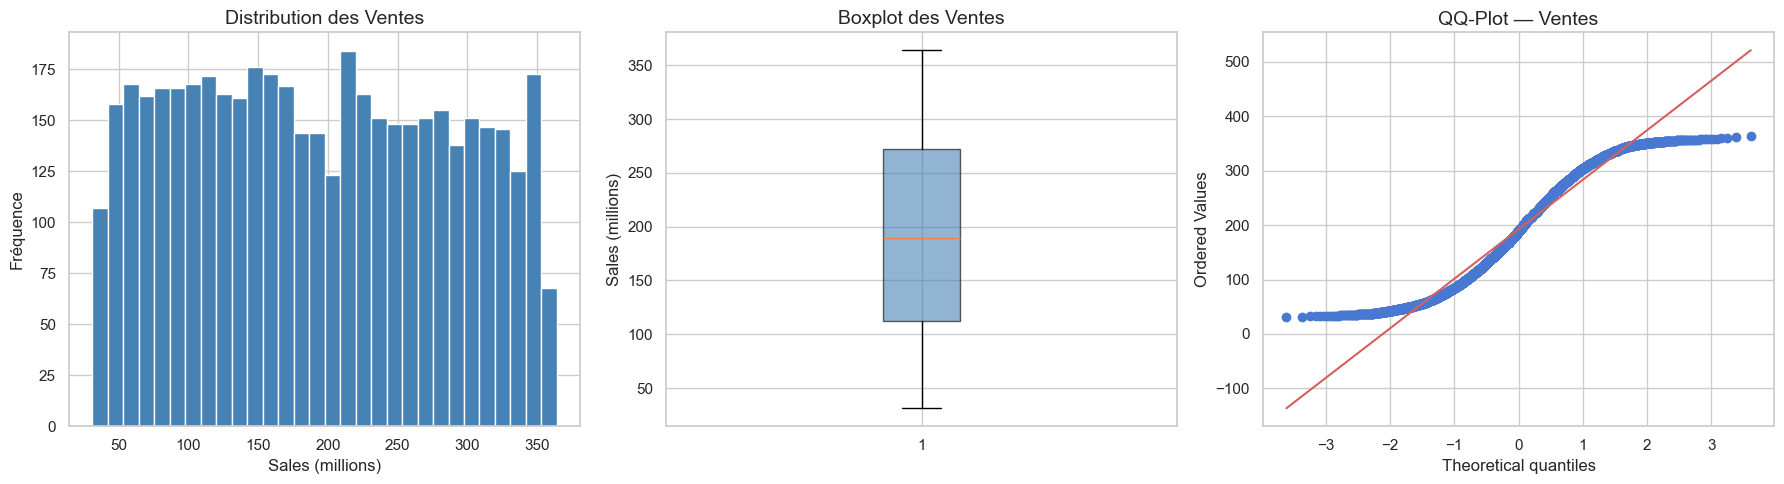

Moyenne   : 192.47 M
Médiane   : 189.23 M
Std       : 93.13 M
Skewness  : 0.070
Kurtosis  : -1.187


In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogramme
axes[0].hist(df['Sales'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution des Ventes')
axes[0].set_xlabel('Sales (millions)')
axes[0].set_ylabel('Fréquence')

# Boxplot
axes[1].boxplot(df['Sales'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot des Ventes')
axes[1].set_ylabel('Sales (millions)')

# QQ-Plot (normalité)
stats.probplot(df['Sales'], plot=axes[2])
axes[2].set_title('QQ-Plot — Ventes')

plt.tight_layout()
plt.savefig('../reports/sales_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats clés
print(f'Moyenne   : {df["Sales"].mean():.2f} M')
print(f'Médiane   : {df["Sales"].median():.2f} M')
print(f'Std       : {df["Sales"].std():.2f} M')
print(f'Skewness  : {df["Sales"].skew():.3f}')
print(f'Kurtosis  : {df["Sales"].kurtosis():.3f}')

## 4. Analyse des variables numériques (budgets)

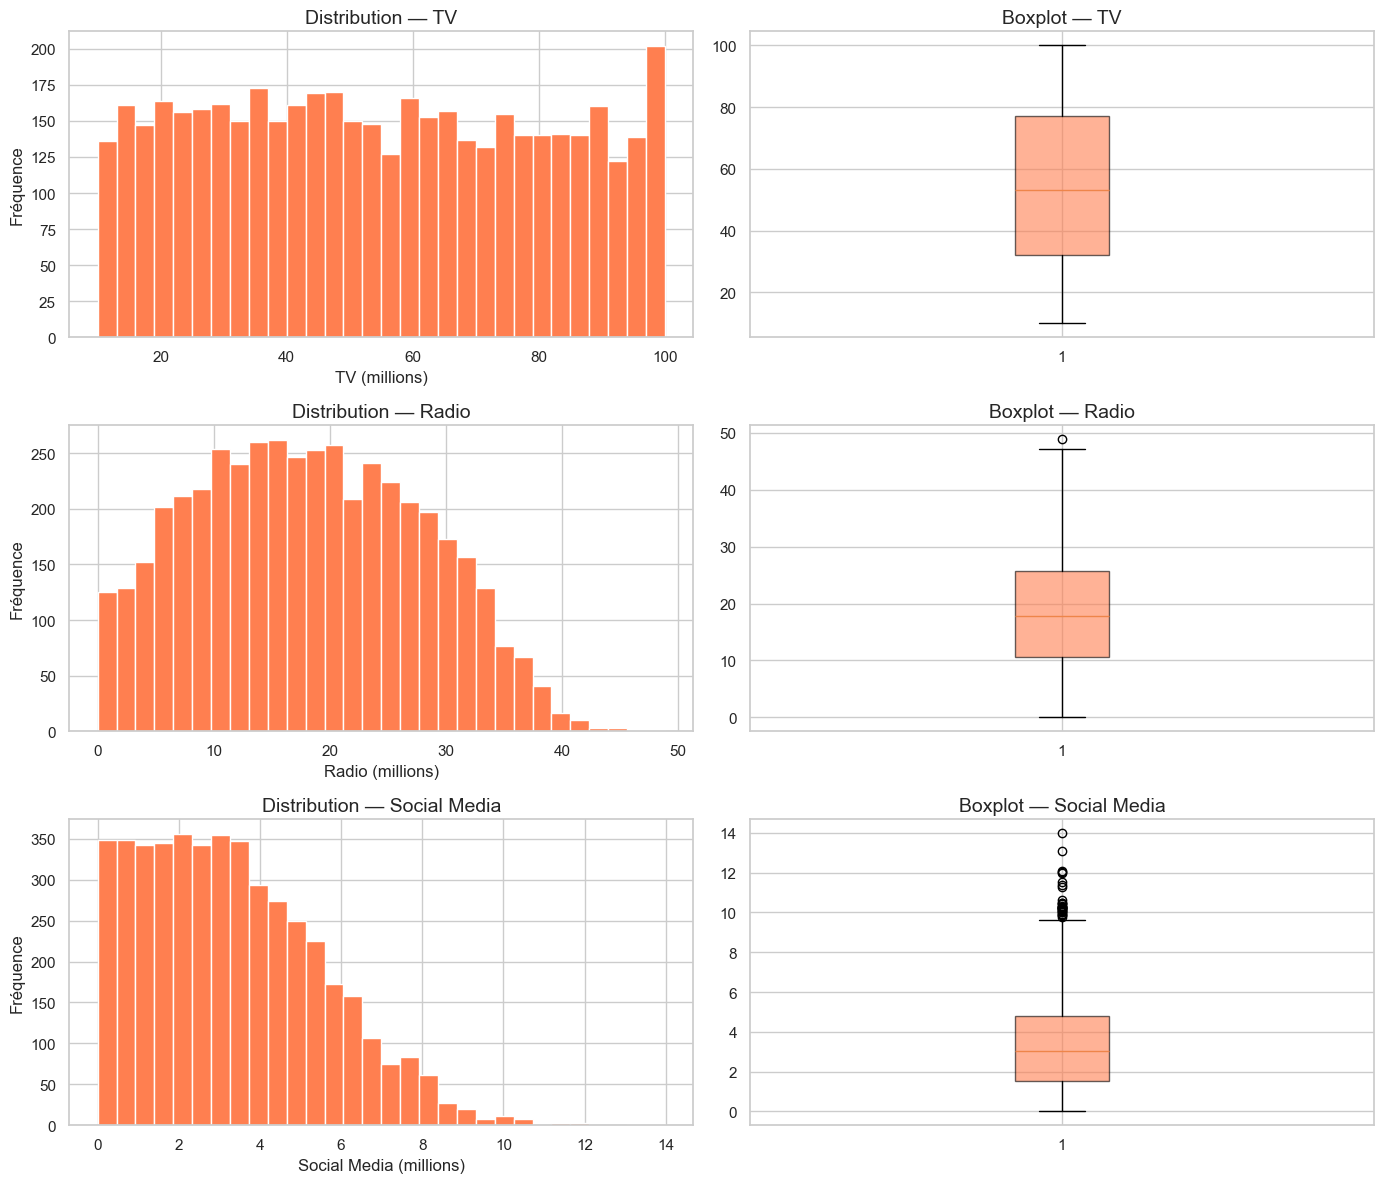

In [40]:
budget_cols = [c for c in num_cols if c != 'Sales']

fig, axes = plt.subplots(len(budget_cols), 2, figsize=(14, 4 * len(budget_cols)))

for i, col in enumerate(budget_cols):
    # Histogramme
    axes[i, 0].hist(df[col], bins=30, color='coral', edgecolor='white')
    axes[i, 0].set_title(f'Distribution — {col}')
    axes[i, 0].set_xlabel(f'{col} (millions)')
    axes[i, 0].set_ylabel('Fréquence')

    # Boxplot
    axes[i, 1].boxplot(df[col], patch_artist=True,
                       boxprops=dict(facecolor='coral', alpha=0.6))
    axes[i, 1].set_title(f'Boxplot — {col}')

plt.tight_layout()
plt.savefig('../reports/budgets_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Analyse de la variable catégorielle : `Influencer`

In [41]:
print('=== DISTRIBUTION DES TYPES D\'INFLUENCEUR ===')
print(df['Influencer'].value_counts())
print(f'\nPourcentages :')
print((df['Influencer'].value_counts(normalize=True) * 100).round(1))

=== DISTRIBUTION DES TYPES D'INFLUENCEUR ===
Influencer
Mega     1156
Micro    1152
Nano     1137
Macro    1121
Name: count, dtype: int64

Pourcentages :
Influencer
Mega     25.3
Micro    25.2
Nano     24.9
Macro    24.6
Name: proportion, dtype: float64


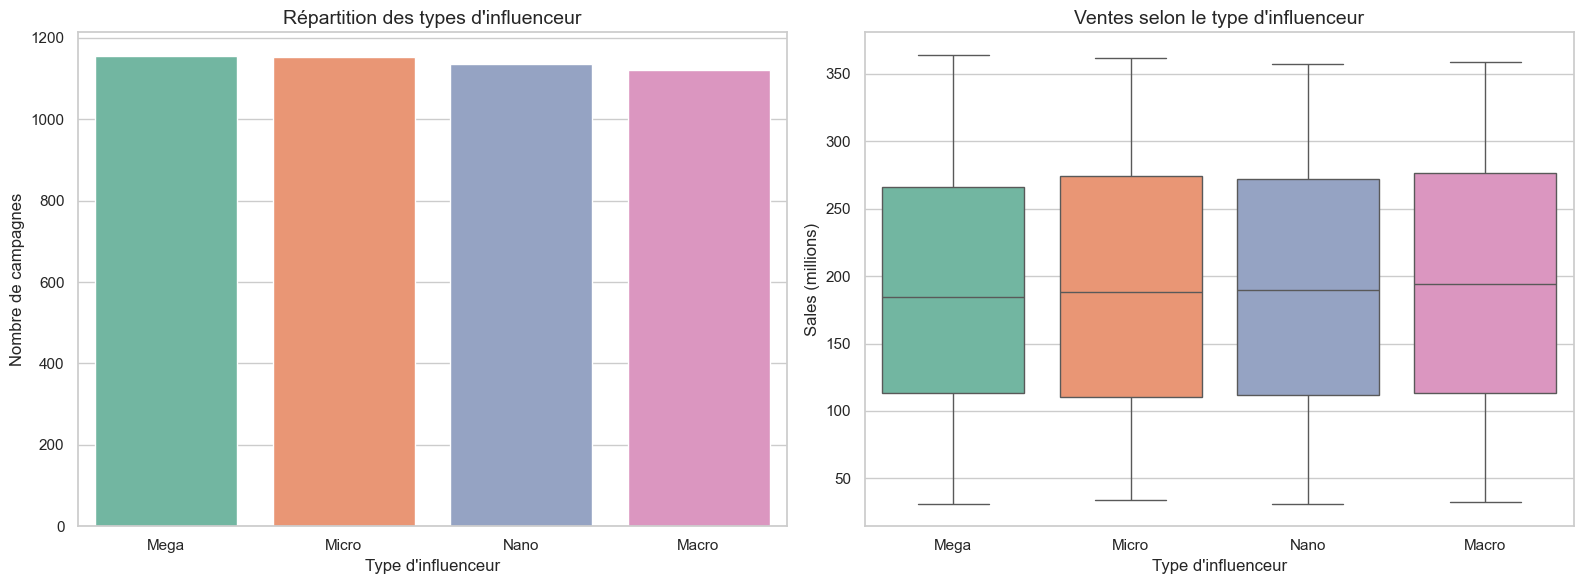


=== VENTES MOYENNES PAR TYPE D'INFLUENCEUR ===
              mean  median    std
Influencer                       
Macro       195.61  194.23  92.57
Mega        190.59  184.17  92.31
Micro       191.81  187.95  94.30
Nano        191.93  189.66  93.38


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Countplot
order = df['Influencer'].value_counts().index
sns.countplot(data=df, x='Influencer', order=order, palette='Set2', ax=axes[0])
axes[0].set_title('Répartition des types d\'influenceur')
axes[0].set_xlabel('Type d\'influenceur')
axes[0].set_ylabel('Nombre de campagnes')

# Boxplot Sales par Influencer
sns.boxplot(data=df, x='Influencer', y='Sales', order=order, palette='Set2', ax=axes[1])
axes[1].set_title('Ventes selon le type d\'influenceur')
axes[1].set_xlabel('Type d\'influenceur')
axes[1].set_ylabel('Sales (millions)')

plt.tight_layout()
plt.savefig('../reports/influencer_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats par catégorie
print('\n=== VENTES MOYENNES PAR TYPE D\'INFLUENCEUR ===')
print(df.groupby('Influencer')['Sales'].agg(['mean', 'median', 'std']).round(2))

## 6. Relations entre budgets et ventes (scatter plots)

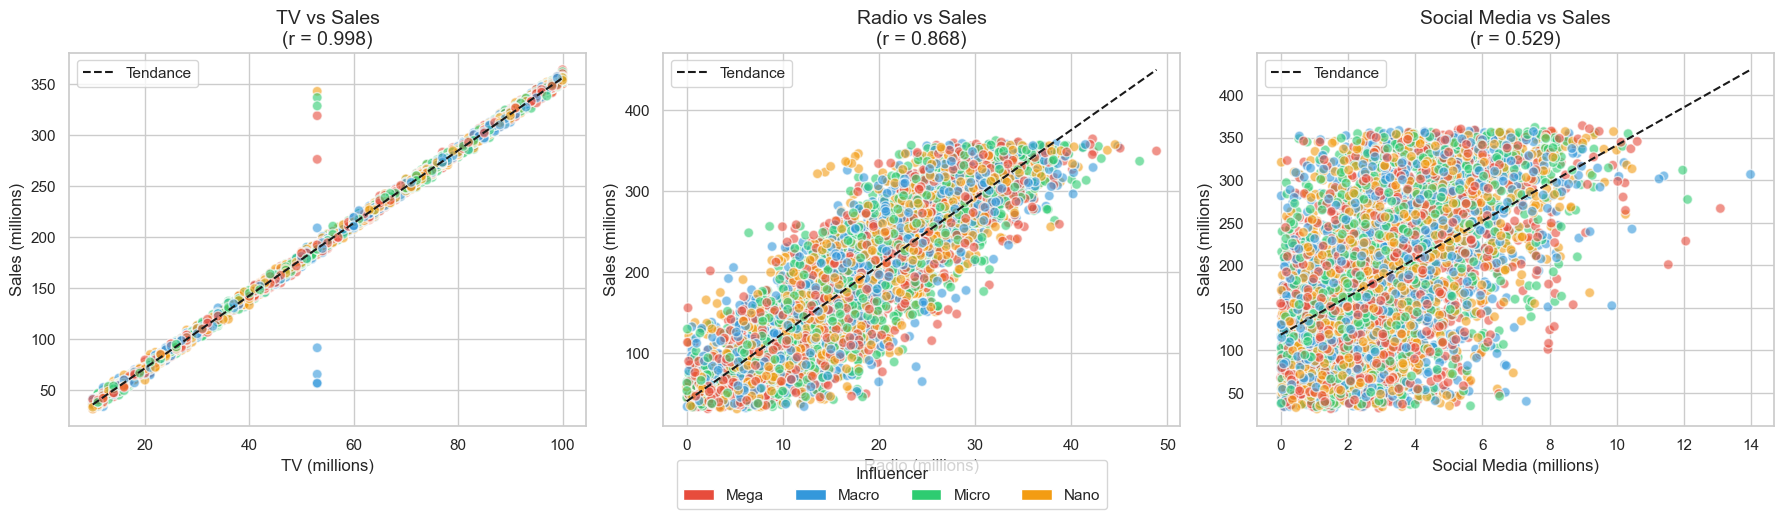

In [43]:
fig, axes = plt.subplots(1, len(budget_cols), figsize=(6 * len(budget_cols), 5))

colors_by_influencer = df['Influencer'].map({
    'Mega': '#e74c3c', 'Macro': '#3498db',
    'Micro': '#2ecc71', 'Nano': '#f39c12'
})

for i, col in enumerate(budget_cols):
    ax = axes[i] if len(budget_cols) > 1 else axes
    ax.scatter(df[col], df['Sales'], c=colors_by_influencer, alpha=0.6, edgecolors='white', s=50)
    
    # Ligne de tendance — version robuste
    mask = df[col].notna() & df['Sales'].notna()  # ← filtre les NaN des deux côtés
    x_clean = df.loc[mask, col].values
    y_clean = df.loc[mask, 'Sales'].values
    
    if len(x_clean) > 1 and x_clean.std() > 0:  # ← évite la division par zéro
        z = np.polyfit(x_clean, y_clean, 1)
        p = np.poly1d(z)
        x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
        ax.plot(x_line, p(x_line), 'k--', linewidth=1.5, label='Tendance')
    
    corr = df[col].corr(df['Sales'])
    ax.set_title(f'{col} vs Sales\n(r = {corr:.3f})')
    ax.set_xlabel(f'{col} (millions)')
    ax.set_ylabel('Sales (millions)')
    ax.legend()

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Mega'),
    Patch(facecolor='#3498db', label='Macro'),
    Patch(facecolor='#2ecc71', label='Micro'),
    Patch(facecolor='#f39c12', label='Nano')
]
fig.legend(handles=legend_elements, title='Influencer',
           loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('../reports/scatter_budgets_vs_sales.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Matrice de corrélation

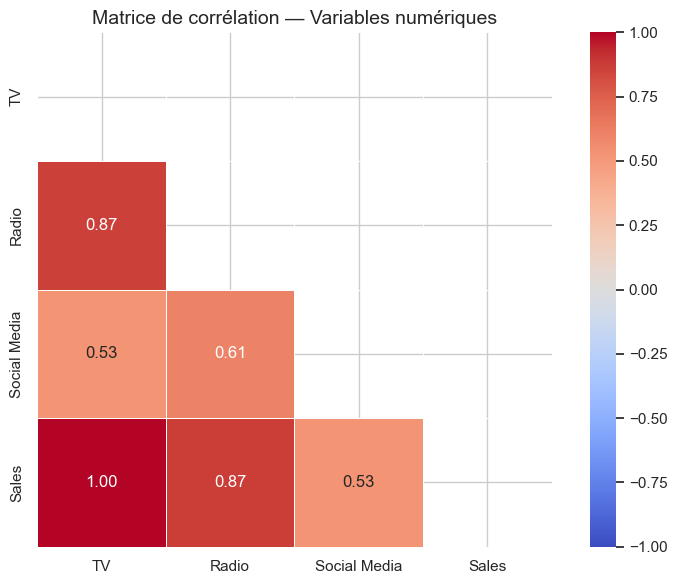

=== CORRÉLATIONS AVEC SALES (triées) ===
TV              0.998
Radio           0.868
Social Media    0.529
Name: Sales, dtype: float64


In [44]:
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    mask=mask, ax=ax, vmin=-1, vmax=1,
    linewidths=0.5, square=True
)
ax.set_title('Matrice de corrélation — Variables numériques')

plt.tight_layout()
plt.savefig('../reports/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Focus sur les corrélations avec Sales
print('=== CORRÉLATIONS AVEC SALES (triées) ===')
print(corr_matrix['Sales'].drop('Sales').sort_values(ascending=False).round(3))

## 8. Détection des outliers (méthode IQR)

In [45]:
print('=== DÉTECTION DES OUTLIERS (méthode IQR) ===')

outlier_report = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_report[col] = {
        'n_outliers': len(outliers),
        'pct': round(len(outliers) / len(df) * 100, 2),
        'lower_bound': round(lower, 2),
        'upper_bound': round(upper, 2)
    }
    print(f'{col:20s} → {len(outliers):3d} outliers ({len(outliers)/len(df)*100:.1f}%)  |  Bornes : [{lower:.2f}, {upper:.2f}]')

=== DÉTECTION DES OUTLIERS (méthode IQR) ===
TV                   →   0 outliers (0.0%)  |  Bornes : [-35.50, 144.50]
Radio                →   1 outliers (0.0%)  |  Bornes : [-12.08, 48.29]
Social Media         →  28 outliers (0.6%)  |  Bornes : [-3.38, 9.71]
Sales                →   0 outliers (0.0%)  |  Bornes : [-127.95, 512.79]


## 9. Feature Engineering exploratoire

In [46]:
df_fe = df.copy()

# Budget total
df_fe['Total_Budget'] = df_fe[budget_cols].sum(axis=1)

# ROI approximatif
df_fe['ROI'] = df_fe['Sales'] / df_fe['Total_Budget']

# Parts relatives des canaux
for col in budget_cols:
    df_fe[f'{col}_share'] = df_fe[col] / df_fe['Total_Budget']

print('=== NOUVELLES FEATURES CRÉÉES ===')
print(df_fe[['Total_Budget', 'ROI'] + [f'{c}_share' for c in budget_cols]].describe().round(3))

=== NOUVELLES FEATURES CRÉÉES ===
       Total_Budget       ROI  TV_share  Radio_share  Social Media_share
count      4566.000  4566.000  4566.000     4566.000            4566.000
mean         75.552     2.547     0.716        0.236               0.048
std          36.095     0.287     0.078        0.070               0.033
min          11.286     0.903     0.377        0.000               0.000
25%          44.452     2.409     0.678        0.204               0.026
50%          74.174     2.552     0.717        0.240               0.042
75%         106.717     2.701     0.758        0.272               0.061
max         156.163     3.749     0.995        0.574               0.326


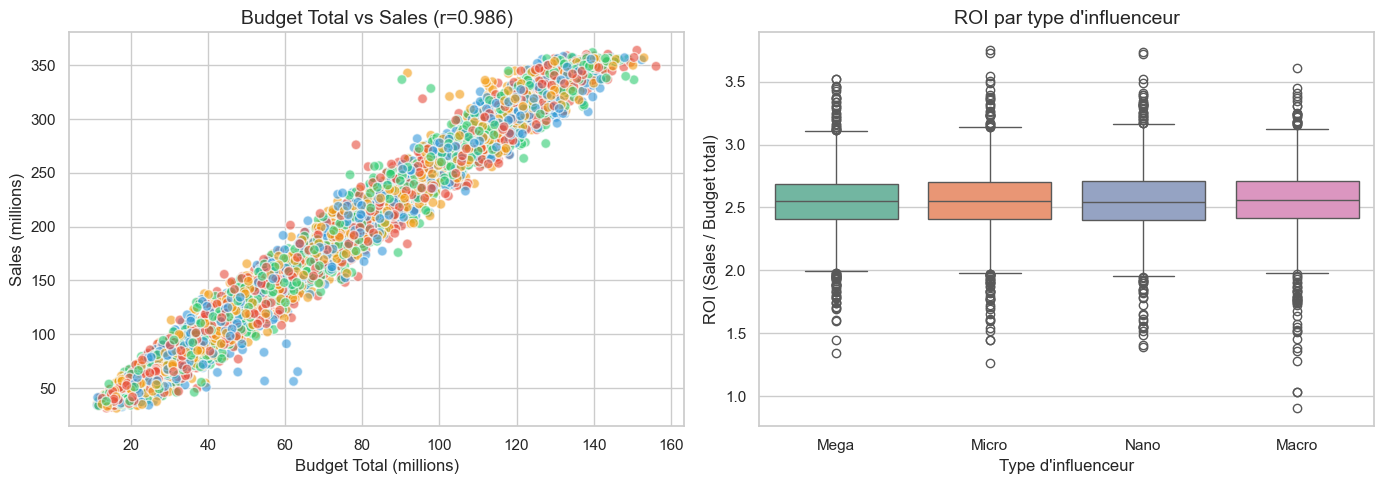

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Budget total vs Sales
axes[0].scatter(df_fe['Total_Budget'], df_fe['Sales'],
                c=colors_by_influencer, alpha=0.6, edgecolors='white', s=50)
corr_tb = df_fe['Total_Budget'].corr(df_fe['Sales'])
axes[0].set_title(f'Budget Total vs Sales (r={corr_tb:.3f})')
axes[0].set_xlabel('Budget Total (millions)')
axes[0].set_ylabel('Sales (millions)')

# ROI par type d'influenceur
sns.boxplot(data=df_fe, x='Influencer', y='ROI',
            order=order, palette='Set2', ax=axes[1])
axes[1].set_title('ROI par type d\'influenceur')
axes[1].set_xlabel('Type d\'influenceur')
axes[1].set_ylabel('ROI (Sales / Budget total)')

plt.tight_layout()
plt.savefig('../reports/feature_engineering_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Analyse par paires (Pairplot)

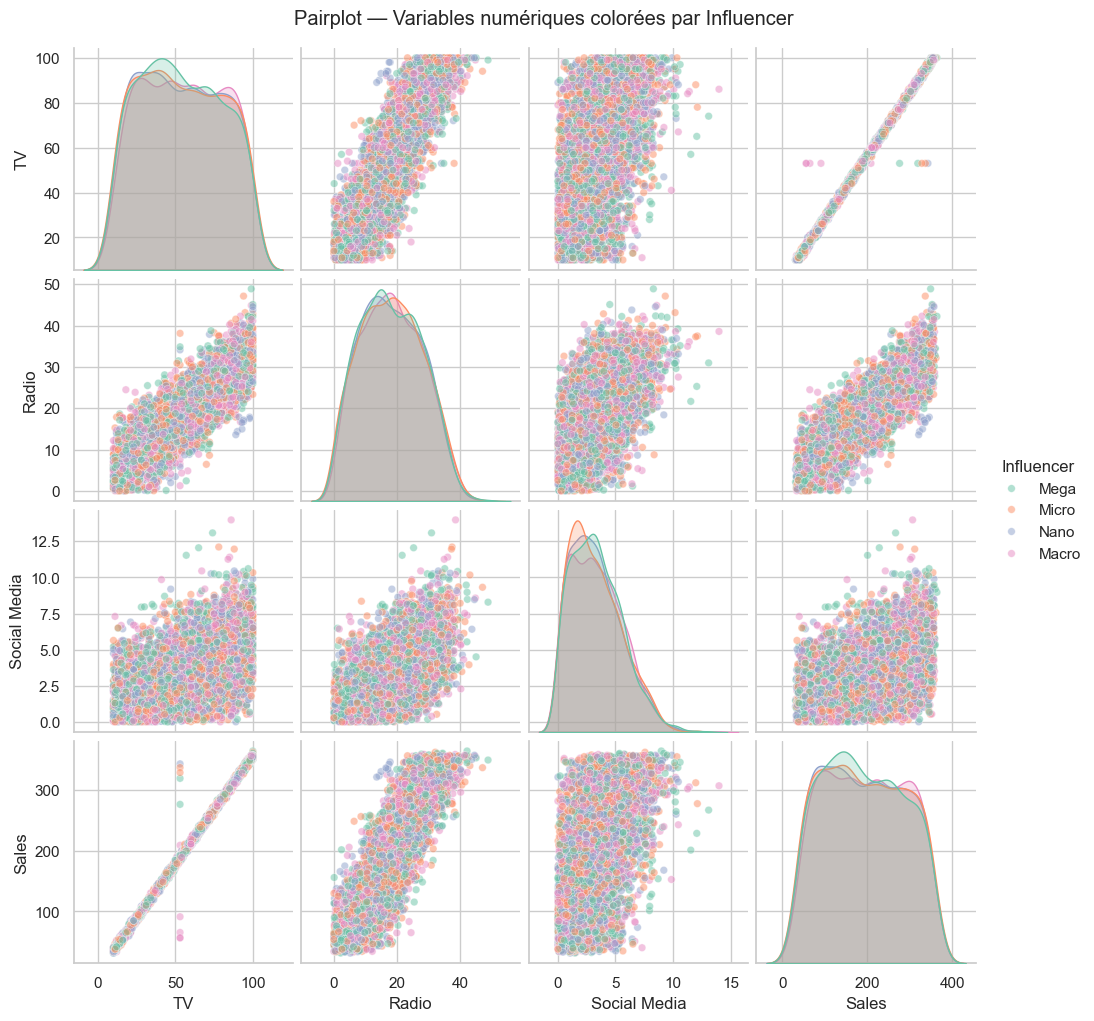

In [48]:
pairplot_cols = num_cols  # TV, Radio, Social Media, Sales

g = sns.pairplot(
    df, vars=pairplot_cols, hue='Influencer',
    plot_kws={'alpha': 0.5, 's': 30},
    diag_kind='kde', palette='Set2'
)
g.fig.suptitle('Pairplot — Variables numériques colorées par Influencer', y=1.02)
plt.savefig('../reports/pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

## 11. Synthèse EDA — Observations et hypothèses métier

In [49]:
print("""
╔══════════════════════════════════════════════════════════╗
║              SYNTHÈSE EDA — OBSERVATIONS CLÉS           ║
╠══════════════════════════════════════════════════════════╣

1 QUALITÉ DES DONNÉES
  → Compléter manuellement après avoir exécuté les cellules ci-dessus.
  Exemple :
  • Pas de valeurs manquantes détectées
  • X doublons supprimés
  • Aucune valeur négative incohérente

2 VARIABLE CIBLE (Sales)
  → Distribution : [normale / légèrement asymétrique ?]
  → Moyenne : XX M | Médiane : XX M | Std : XX M
  → Présence d'outliers : [oui/non]

3 CORRÉLATIONS AVEC SALES
  → Canal le plus corrélé : [TV / Social Media / Radio ?]
  → Corrélation plus faible : [Radio ?]
  → Pas de multicolinéarité forte entre les canaux : [oui/non]

4 IMPACT DU TYPE D'INFLUENCEUR
  → Les campagnes Mega semblent générer [plus/moins] de ventes
  → Nano-influenceurs associés à des budgets [faibles/élevés]

5 HYPOTHÈSES POUR LA MODÉLISATION
  1. Le budget TV est probablement le prédicteur principal des ventes
  2. Le type d'influenceur modère l'effet des budgets
  3. Des effets non-linéaires ou d'interaction sont possibles
     → justifie l'usage de Random Forest / Gradient Boosting
  4. Une saturation publicitaire peut apparaître à haut budget

6 PROCHAINES ÉTAPES
  → 02_Preprocessing.py : nettoyage, encodage, pipeline sklearn
  → 03_Modeling.py : entraînement des 4 modèles comparés
""")


╔══════════════════════════════════════════════════════════╗
║              SYNTHÈSE EDA — OBSERVATIONS CLÉS           ║
╠══════════════════════════════════════════════════════════╣

1 QUALITÉ DES DONNÉES
  → Compléter manuellement après avoir exécuté les cellules ci-dessus.
  Exemple :
  • Pas de valeurs manquantes détectées
  • X doublons supprimés
  • Aucune valeur négative incohérente

2 VARIABLE CIBLE (Sales)
  → Distribution : [normale / légèrement asymétrique ?]
  → Moyenne : XX M | Médiane : XX M | Std : XX M
  → Présence d'outliers : [oui/non]

3 CORRÉLATIONS AVEC SALES
  → Canal le plus corrélé : [TV / Social Media / Radio ?]
  → Corrélation plus faible : [Radio ?]
  → Pas de multicolinéarité forte entre les canaux : [oui/non]

4 IMPACT DU TYPE D'INFLUENCEUR
  → Les campagnes Mega semblent générer [plus/moins] de ventes
  → Nano-influenceurs associés à des budgets [faibles/élevés]

5 HYPOTHÈSES POUR LA MODÉLISATION
  1. Le budget TV est probablement le prédicteur principal d

In [50]:
# Sauvegarde du dataset nettoyé si besoin
df_fe.to_csv('../data/marketing_and_sales_eda.csv', index=False)
print(' Dataset enrichi sauvegardé dans data/marketing_and_sales_eda.csv')

 Dataset enrichi sauvegardé dans data/marketing_and_sales_eda.csv
